# 01 — Exploratory Data Analysis

Goal: understand the shape, quality, and key patterns in the diabetes readmissions dataset before feature engineering.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')
from data_prep import basic_clean_pipeline

pd.set_option('display.max_columns', 60)

## Load and clean
Uses `src/data_prep.py` to load the raw CSV, replace `?` with NaN, exclude hospice/expired dispositions, and create the `readmitted_30d` target.

Alternatively, load `data/processed/model_input.csv` if you built it via the SQL layer.

In [4]:
df = basic_clean_pipeline('../data/raw/diabetic_data.csv')
df.shape

(99343, 51)

In [5]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_30d
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,0
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,0
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,0
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,0
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0


## Missing values
Check which columns need imputation or dropping strategy decisions.

In [6]:
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
missing_pct[missing_pct > 0]

weight               96.854333
max_glu_serum        94.813928
A1Cresult            83.054669
medical_specialty    48.937520
payer_code           39.658557
race                  2.248774
diag_3                1.428384
diag_2                0.358354
diag_1                0.020132
dtype: float64

## Target distribution
Confirm class imbalance — expect roughly 11% positive (`<30`).

In [7]:
df['readmitted_30d'].value_counts(normalize=True)

readmitted_30d
0    0.886112
1    0.113888
Name: proportion, dtype: float64

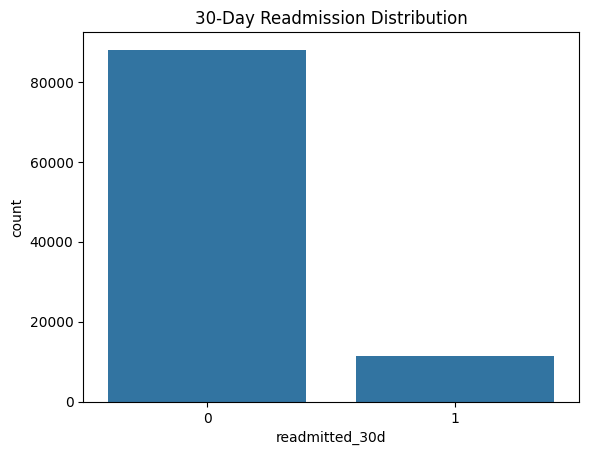

In [8]:
sns.countplot(data=df, x='readmitted_30d')
plt.title('30-Day Readmission Distribution')
plt.show()

## Readmission rate by key segments
Age, length of stay, discharge disposition, number of prior inpatient visits.

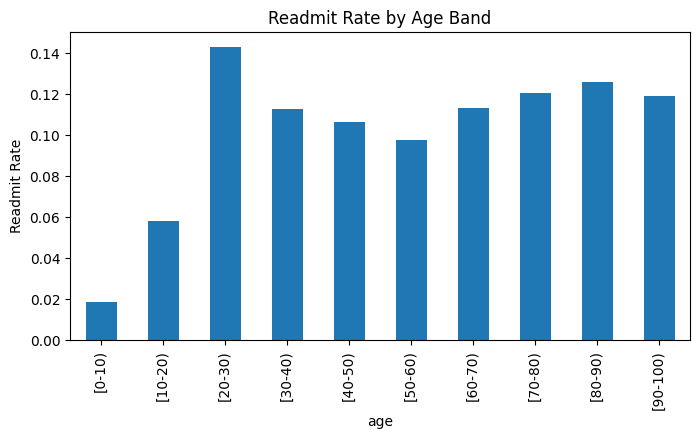

In [9]:
df.groupby('age')['readmitted_30d'].mean().sort_index().plot(kind='bar', figsize=(8,4), title='Readmit Rate by Age Band')
plt.ylabel('Readmit Rate')
plt.show()

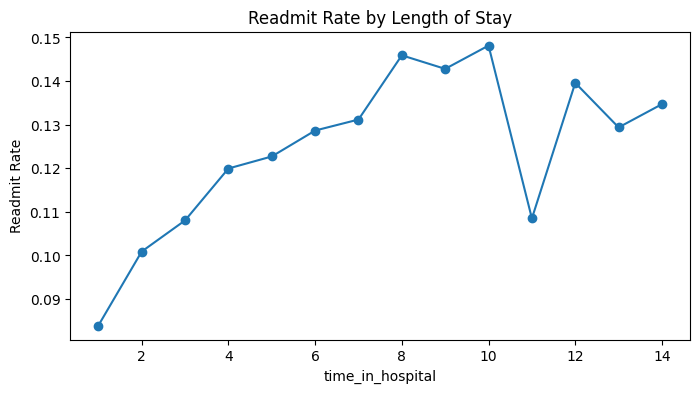

In [10]:
df.groupby('time_in_hospital')['readmitted_30d'].mean().plot(kind='line', marker='o', figsize=(8,4), title='Readmit Rate by Length of Stay')
plt.ylabel('Readmit Rate')
plt.show()

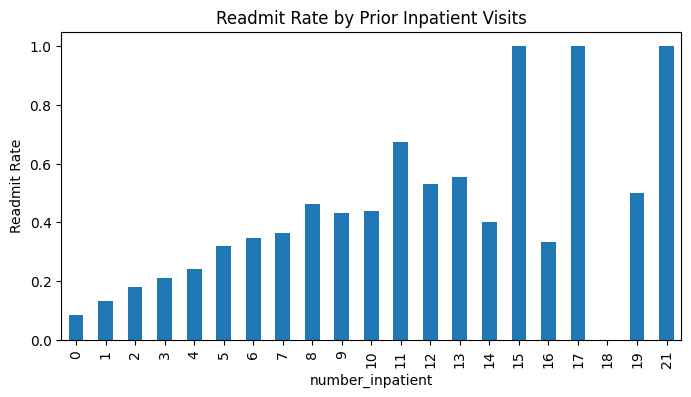

In [11]:
df.groupby('number_inpatient')['readmitted_30d'].mean().plot(kind='bar', figsize=(8,4), title='Readmit Rate by Prior Inpatient Visits')
plt.ylabel('Readmit Rate')
plt.show()

## Notes / findings
_(fill in as you explore — this becomes the basis for reports/findings_summary.md)_